# U-Net Time Cross-Validation

Expanding window cross-validation with 5 fold cutoffs.
For each fold, evaluates on:
1. All cells (full map)
2. Changing cells only (cells that change at least once in full period)

Compares U-Net against no-change baseline for each fold.

In [1]:
# ── Imports and Paths ─────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.metrics import classification_report, f1_score, accuracy_score
from pathlib import Path
import copy
import warnings
warnings.filterwarnings('ignore')

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)

PROJECT_ROOT = Path("..").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
REPORTS      = PROJECT_ROOT / "reports" / "figures"
REPORTS.mkdir(parents=True, exist_ok=True)
CHECKPOINTS  = PROJECT_ROOT / "notebooks" / "outputs"
CHECKPOINTS.mkdir(parents=True, exist_ok=True)

# Device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

c:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using CPU


## Load Data

In [2]:
# ── Load features and target ──────────────────────────────────────────────────
features_path = DATA_PROC / "myanmar_priogrid_features.csv"
target_path   = DATA_PROC / "10_target_variable.parquet"

features = pd.read_csv(features_path)
features["year_month"] = features["year_month"].astype(str)

target = pd.read_parquet(target_path)
target["year_month"] = target["year_month"].astype(str)

print(f"Features: {len(features):,} rows x {features.shape[1]} cols")
print(f"Target:   {len(target):,} rows")
print(f"Date range: {features['year_month'].min()} to {features['year_month'].max()}")

# ── Input feature channels (same as original U-Net) ───────────────────────────
INPUT_FEATURES = [
    "total_events",
    "total_fatalities",
    "events_gov",
    "events_nug",
    "events_ula",
    "events_kio",
    "gov_vs_civilians",
    "gov_event_share",
    "total_events_lag1",
    "total_fatalities_lag1",
]

LABEL_MAP = {"gov": 0, "opo": 1, "uncertain": 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}
CLASS_NAMES = ["gov", "opo", "uncertain"]
NUM_CHANNELS = len(INPUT_FEATURES)
NUM_CLASSES  = 3

print(f"\nInput channels: {NUM_CHANNELS}")
print(f"Label map: {LABEL_MAP}")

Features: 12,338 rows x 47 cols
Target:   5,238 rows
Date range: 2021-02 to 2026-03

Input channels: 10
Label map: {'gov': 0, 'opo': 1, 'uncertain': 2}


## Setup: Grid Coordinates and Changing Cells

In [3]:
# ── PRIOGRID coordinates ──────────────────────────────────────────────────────
def gid_to_rowcol(gid):
    row = (gid - 1) // 720
    col = (gid - 1) % 720
    return row, col

all_gids   = features["priogrid_gid"].unique()
gid_coords = {}
for gid in all_gids:
    row, col = gid_to_rowcol(gid)
    gid_coords[gid] = {"global_row": row, "global_col": col}

coords_df = pd.DataFrame.from_dict(gid_coords, orient="index")
coords_df.index.name = "priogrid_gid"

min_global_row = coords_df["global_row"].min()
min_global_col = coords_df["global_col"].min()
coords_df["local_row"] = coords_df["global_row"] - min_global_row
coords_df["local_col"] = coords_df["global_col"] - min_global_col

RASTER_H = coords_df["local_row"].max() + 1
RASTER_W = coords_df["local_col"].max() + 1
PAD_H    = int(np.ceil(RASTER_H / 8) * 8)
PAD_W    = int(np.ceil(RASTER_W / 8) * 8)

gid_to_local = coords_df[["local_row", "local_col"]].to_dict("index")

print(f"Raster dimensions: {RASTER_H} x {RASTER_W} (padded: {PAD_H} x {PAD_W})")

# ── Identify changing cells (full period) ─────────────────────────────────────
target_sorted = target.sort_values(["priogrid_gid", "year_month"])
target_sorted["prev"] = target_sorted.groupby("priogrid_gid")["target"].shift(1)
target_sorted["changed"] = (
    target_sorted["prev"].notna() &
    (target_sorted["target"] != target_sorted["prev"])
)
CHANGING_CELLS = set(target_sorted[target_sorted["changed"]]["priogrid_gid"].unique())
print(f"Cells that change at least once: {len(CHANGING_CELLS)} / {target['priogrid_gid'].nunique()}")

Raster dimensions: 36 x 15 (padded: 40 x 16)
Cells that change at least once: 94 / 185


## Helper Functions

In [4]:
# ── Build rasters for a given train cutoff ────────────────────────────────────
def build_rasters(train_cutoff):
    """Build raster arrays for a given train/val split cutoff."""
    # Join features with target
    target_enc = target.copy()
    target_enc["label_int"] = target_enc["target"].map(LABEL_MAP)
    labelled = features.merge(
        target_enc[["priogrid_gid", "year_month", "target", "label_int"]],
        on=["priogrid_gid", "year_month"], how="inner"
    )

    # Normalise using training set statistics only
    train_mask = labelled["year_month"] <= train_cutoff
    feat_means = labelled.loc[train_mask, INPUT_FEATURES].mean()
    feat_stds  = labelled.loc[train_mask, INPUT_FEATURES].std().replace(0, 1)
    labelled[INPUT_FEATURES] = (labelled[INPUT_FEATURES] - feat_means) / feat_stds

    # Build monthly rasters
    months     = sorted(labelled["year_month"].unique())
    X_rasters, y_rasters, masks, month_keys = [], [], [], []

    for month in months:
        md_data  = labelled[labelled["year_month"] == month]
        X_raster = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)
        y_raster = np.full((PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
        mask     = np.zeros((PAD_H, PAD_W), dtype=np.uint8)

        for _, row in md_data.iterrows():
            gid = row["priogrid_gid"]
            if gid not in gid_to_local:
                continue
            lr = gid_to_local[gid]["local_row"]
            lc = gid_to_local[gid]["local_col"]
            X_raster[lr, lc, :] = row[INPUT_FEATURES].values
            y_raster[lr, lc]    = row["label_int"]
            mask[lr, lc]        = 1

        X_rasters.append(np.transpose(X_raster, (2, 0, 1)))
        y_rasters.append(y_raster)
        masks.append(mask)
        month_keys.append(month)

    X_array = np.stack(X_rasters)
    y_array = np.stack(y_rasters)
    m_array = np.stack(masks)

    train_idx = [i for i, m in enumerate(month_keys) if m <= train_cutoff]
    val_idx   = [i for i, m in enumerate(month_keys) if m > train_cutoff]

    return (X_array[train_idx], y_array[train_idx], m_array[train_idx],
            X_array[val_idx],   y_array[val_idx],   m_array[val_idx],
            month_keys, train_idx, val_idx, labelled)


# ── PyTorch Dataset ────────────────────────────────────────────────────────────
class MyanmarRasterDataset(Dataset):
    def __init__(self, X, y, mask, augment=False):
        self.X = X.astype(np.float32)
        self.y = y.astype(np.int64)
        self.mask = mask.astype(np.uint8)
        self.augment = augment
        self.T = len(X)

    def __len__(self): return self.T

    def __getitem__(self, idx):
        X    = torch.from_numpy(self.X[idx])
        y    = torch.from_numpy(self.y[idx])
        mask = torch.from_numpy(self.mask[idx])
        if self.augment and torch.rand(1).item() > 0.5:
            X    = torch.flip(X,    dims=[2])
            y    = torch.flip(y,    dims=[1])
            mask = torch.flip(mask, dims=[1])
        return X, y, mask


# ── Build fresh model ─────────────────────────────────────────────────────────
def build_model(labelled, train_cutoff):
    """Build a fresh U-Net model with class weights computed from training set."""
    model = smp.Unet(
        encoder_name="resnet34",
        encoder_weights="imagenet",
        in_channels=NUM_CHANNELS,
        classes=NUM_CLASSES,
        activation=None,
        decoder_channels=(128, 64, 32, 16),
        encoder_depth=4,
    ).to(DEVICE)

    # Class weights from training set
    train_labels = labelled[labelled["year_month"] <= train_cutoff]["target"]
    counts = np.array([
        (train_labels == "gov").sum(),
        (train_labels == "opo").sum(),
        (train_labels == "uncertain").sum()
    ], dtype=np.float32)
    counts = np.maximum(counts, 1)
    weights = len(train_labels) / (NUM_CLASSES * counts)
    weight_tensor = torch.tensor(weights, dtype=torch.float32).to(DEVICE)

    ce_loss   = nn.CrossEntropyLoss(weight=weight_tensor)
    dice_loss = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)

    def combined_loss(preds, targets, mask):
        masked_targets = targets.clone()
        masked_targets[mask == 0] = 0
        preds_hwc     = preds.permute(0, 2, 3, 1)
        valid_preds   = preds_hwc[mask == 1]
        valid_targets = targets[mask == 1]
        if valid_preds.shape[0] == 0:
            return torch.tensor(0.0, requires_grad=True, device=preds.device)
        ce = ce_loss(valid_preds, valid_targets)
        dc = dice_loss(preds, masked_targets)
        return 0.5 * ce + 0.5 * dc

    decoder_params = (list(model.decoder.parameters()) +
                      list(model.segmentation_head.parameters()))
    optimizer = optim.Adam(decoder_params, lr=1e-4, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min",
                                                      patience=10, factor=0.5)
    return model, combined_loss, optimizer, scheduler


# ── Training loop ─────────────────────────────────────────────────────────────
def train_model(model, combined_loss, optimizer, scheduler,
                train_loader, val_loader, num_epochs=100, fold_name="fold"):
    """Two-phase training: freeze encoder for first 30 epochs, then unfreeze."""
    PHASE2_EPOCH = 30
    best_val_loss = float("inf")
    best_weights  = None
    history = []

    for epoch in range(1, num_epochs + 1):
        # Phase 2: unfreeze encoder
        if epoch == PHASE2_EPOCH + 1:
            for param in model.encoder.parameters():
                param.requires_grad = True
            encoder_params = list(model.encoder.parameters())
            optimizer.add_param_group({"params": encoder_params, "lr": 1e-5})
            print(f"  Epoch {epoch}: encoder unfrozen")

        # Training
        model.train()
        train_losses = []
        for X_batch, y_batch, mask_batch in train_loader:
            X_batch    = X_batch.to(DEVICE)
            y_batch    = y_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)
            optimizer.zero_grad()
            logits = model(X_batch)
            loss   = combined_loss(logits, y_batch, mask_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_losses.append(loss.item())

        # Validation
        model.eval()
        val_losses = []
        with torch.no_grad():
            for X_batch, y_batch, mask_batch in val_loader:
                X_batch    = X_batch.to(DEVICE)
                y_batch    = y_batch.to(DEVICE)
                mask_batch = mask_batch.to(DEVICE)
                logits = model(X_batch)
                loss   = combined_loss(logits, y_batch, mask_batch)
                val_losses.append(loss.item())

        train_loss = np.mean(train_losses)
        val_loss   = np.mean(val_losses)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights  = copy.deepcopy(model.state_dict())

        history.append({"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss})

        if epoch % 20 == 0:
            print(f"  [{fold_name}] Epoch {epoch}/{num_epochs} — "
                  f"train: {train_loss:.4f}  val: {val_loss:.4f}")

    model.load_state_dict(best_weights)
    return model, history


# ── Evaluate model ────────────────────────────────────────────────────────────
def evaluate_model(model, val_loader, labelled, val_months, changing_cells):
    """Evaluate on all cells and changing cells only. Returns metrics dict."""
    model.eval()
    all_true, all_pred, all_gids_eval = [], [], []

    # Build gid lookup for val months
    val_labelled = labelled[labelled["year_month"].isin(val_months)]

    with torch.no_grad():
        for i, (X_batch, y_batch, mask_batch) in enumerate(val_loader):
            X_batch    = X_batch.to(DEVICE)
            y_batch    = y_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)
            logits = model(X_batch)
            probs  = torch.softmax(logits, dim=1)
            preds  = torch.argmax(probs, dim=1)

            valid_mask = mask_batch == 1
            all_true.extend(y_batch[valid_mask].cpu().numpy().tolist())
            all_pred.extend(preds[valid_mask].cpu().numpy().tolist())

    all_true = np.array(all_true)
    all_pred = np.array(all_pred)

    def metrics(true, pred, label):
        if len(true) == 0:
            return {}
        acc      = accuracy_score(true, pred)
        macro_f1 = f1_score(true, pred, average="macro",
                            labels=[0,1,2], zero_division=0)
        report   = classification_report(true, pred, labels=[0,1,2],
                                         target_names=CLASS_NAMES,
                                         output_dict=True, zero_division=0)
        return {
            f"{label}_n":          len(true),
            f"{label}_accuracy":   round(acc, 3),
            f"{label}_macro_f1":   round(macro_f1, 3),
            f"{label}_gov_f1":     round(report["gov"]["f1-score"], 3),
            f"{label}_opo_f1":     round(report["opo"]["f1-score"], 3),
            f"{label}_unc_f1":     round(report["uncertain"]["f1-score"], 3),
        }

    # All cells
    result = metrics(all_true, all_pred, "all")

    # Changing cells only — need per-cell gid info
    # Rebuild predictions with gid tracking
    all_true_c, all_pred_c = [], []
    with torch.no_grad():
        for i, (X_batch, y_batch, mask_batch) in enumerate(val_loader):
            X_batch    = X_batch.to(DEVICE)
            y_batch    = y_batch.to(DEVICE)
            mask_batch = mask_batch.to(DEVICE)
            logits = model(X_batch)
            probs  = torch.softmax(logits, dim=1)
            preds  = torch.argmax(probs, dim=1)

            for b in range(X_batch.shape[0]):
                mask_b = mask_batch[b].cpu().numpy()
                y_b    = y_batch[b].cpu().numpy()
                pred_b = preds[b].cpu().numpy()
                # Find which gids correspond to labelled positions in this raster
                rows, cols = np.where(mask_b == 1)
                for r, c in zip(rows, cols):
                    # reverse lookup: local (r,c) -> gid
                    pass  # gid lookup needed

    # Simpler: use labelled dataframe with val months
    # Get predictions by reordering through the labelled dataframe order
    val_df = labelled[labelled["year_month"].isin(val_months)].copy()
    val_df["true_int"] = val_df["target"].map(LABEL_MAP)

    # Match prediction order (same order as DataLoader iteration)
    # all_true already matches val_df order if DataLoader is not shuffled
    if len(all_true) == len(val_df):
        val_df = val_df.reset_index(drop=True)
        val_df["pred_int"] = all_pred

        # Changing cells subset
        changing_df = val_df[val_df["priogrid_gid"].isin(changing_cells)]
        result.update(metrics(changing_df["true_int"].values,
                              changing_df["pred_int"].values, "changing"))

    return result


# ── No-change baseline ────────────────────────────────────────────────────────
def no_change_baseline(labelled, train_cutoff, changing_cells):
    """Compute no-change baseline on val set (all cells and changing cells)."""
    df = labelled.sort_values(["priogrid_gid", "year_month"]).copy()
    df["prev"] = df.groupby("priogrid_gid")["target"].shift(1)
    df["changed_flag"] = df["prev"].notna() & (df["target"] != df["prev"])

    val_df = df[df["year_month"] > train_cutoff].dropna(subset=["prev"]).copy()
    val_df["true_int"] = val_df["target"].map(LABEL_MAP)
    val_df["pred_int"] = val_df["prev"].map(LABEL_MAP)

    def nc_metrics(sub, label):
        if len(sub) == 0: return {}
        true = sub["true_int"].values
        pred = sub["pred_int"].values
        acc      = accuracy_score(true, pred)
        macro_f1 = f1_score(true, pred, average="macro",
                            labels=[0,1,2], zero_division=0)
        n_changed = (true != pred).sum()
        return {
            f"nc_{label}_n":        len(true),
            f"nc_{label}_accuracy": round(acc, 3),
            f"nc_{label}_macro_f1": round(macro_f1, 3),
            f"nc_{label}_change_pct": round(n_changed/len(true)*100, 1),
        }

    result = nc_metrics(val_df, "all")
    changing_val = val_df[val_df["priogrid_gid"].isin(changing_cells)]
    result.update(nc_metrics(changing_val, "changing"))
    return result

print("Helper functions defined.")

Helper functions defined.


## Cross-Validation Loop

Trains U-Net for each fold cutoff and evaluates against no-change baseline.

In [5]:
# ── Fold cutoffs ──────────────────────────────────────────────────────────────
FOLD_CUTOFFS = [
    "2024-03",   # train 5m,  validate 24m — before activity spike
    "2024-07",   # train 9m,  validate 20m — just before August 2024 peak
    "2024-09",   # train 11m, validate 18m — after the peak
    "2025-03",   # train 17m, validate 12m — halfway
    "2025-09",   # train 23m, validate 6m  — original split
]

NUM_EPOCHS = 100   # reduce from 200 to save time; increase for final run
BATCH_SIZE = 8

all_results = []

for fold_i, train_cutoff in enumerate(FOLD_CUTOFFS):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_i+1}/{len(FOLD_CUTOFFS)} — cutoff: {train_cutoff}")
    print(f"{'='*60}")

    # Build rasters
    print("Building rasters...")
    (X_train, y_train, m_train,
     X_val,   y_val,   m_val,
     month_keys, train_idx, val_idx, labelled) = build_rasters(train_cutoff)

    val_months = [month_keys[i] for i in val_idx]
    print(f"  Train: {len(train_idx)} months | Val: {len(val_idx)} months")
    print(f"  Val months: {val_months[0]} to {val_months[-1]}")

    # DataLoaders
    train_dataset = MyanmarRasterDataset(X_train, y_train, m_train, augment=True)
    val_dataset   = MyanmarRasterDataset(X_val,   y_val,   m_val,   augment=False)
    train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

    # Build fresh model
    print("Building model...")
    model, loss_fn, optimizer, scheduler = build_model(labelled, train_cutoff)

    # Train
    print(f"Training for {NUM_EPOCHS} epochs...")
    model, history = train_model(model, loss_fn, optimizer, scheduler,
                                  train_loader, val_loader,
                                  num_epochs=NUM_EPOCHS,
                                  fold_name=f"fold{fold_i+1}")

    # Evaluate U-Net
    print("Evaluating...")
    unet_metrics = evaluate_model(model, val_loader, labelled,
                                   val_months, CHANGING_CELLS)

    # No-change baseline
    nc_metrics = no_change_baseline(labelled, train_cutoff, CHANGING_CELLS)

    # Combine results
    fold_result = {
        "fold":          fold_i + 1,
        "train_cutoff":  train_cutoff,
        "n_train_months": len(train_idx),
        "n_val_months":   len(val_idx),
    }
    fold_result.update({f"unet_{k}": v for k, v in unet_metrics.items()})
    fold_result.update(nc_metrics)
    all_results.append(fold_result)

    # Save model checkpoint
    ckpt_path = CHECKPOINTS / f"unet_fold{fold_i+1}_{train_cutoff}.pt"
    torch.save(model.state_dict(), ckpt_path)
    print(f"  Checkpoint saved: {ckpt_path.name}")

    # Quick summary for this fold
    print(f"\n  Results summary:")
    print(f"  {'Metric':<25} {'U-Net':>8} {'No-change':>10}")
    print(f"  {'-'*45}")
    for subset in ["all", "changing"]:
        u_f1 = fold_result.get(f"unet_{subset}_macro_f1", "N/A")
        n_f1 = fold_result.get(f"nc_{subset}_macro_f1", "N/A")
        print(f"  {subset + ' cells macro F1':<25} {str(u_f1):>8} {str(n_f1):>10}")

results_df = pd.DataFrame(all_results)
print(f"\n\nAll folds complete.")


FOLD 1/5 — cutoff: 2024-03
Building rasters...
  Train: 5 months | Val: 24 months
  Val months: 2024-04 to 2026-03
Building model...
Training for 100 epochs...
  [fold1] Epoch 20/100 — train: 0.7530  val: 0.9984
  Epoch 31: encoder unfrozen
  [fold1] Epoch 40/100 — train: 0.6908  val: 1.0040
  [fold1] Epoch 60/100 — train: 0.6503  val: 1.0383
  [fold1] Epoch 80/100 — train: 0.6778  val: 1.0543
  [fold1] Epoch 100/100 — train: 0.6517  val: 1.0589
Evaluating...
  Checkpoint saved: unet_fold1_2024-03.pt

  Results summary:
  Metric                       U-Net  No-change
  ---------------------------------------------
  all cells macro F1           0.392      0.935
  changing cells macro F1       0.34      0.901

FOLD 2/5 — cutoff: 2024-07
Building rasters...
  Train: 9 months | Val: 20 months
  Val months: 2024-08 to 2026-03
Building model...
Training for 100 epochs...
  [fold2] Epoch 20/100 — train: 0.7816  val: 0.8738
  Epoch 31: encoder unfrozen
  [fold2] Epoch 40/100 — train: 0.6340 

## Final Summary Comparison

In [6]:
# ── Summary table ─────────────────────────────────────────────────────────────
print("=" * 70)
print("FINAL SUMMARY: U-Net vs No-Change Baseline")
print("=" * 70)

print(f"\n{'Fold':<6} {'Cutoff':<10} {'ValM':>5} | {'U-Net All':>10} {'NC All':>8} | {'U-Net Change':>13} {'NC Change':>10}")
print("-" * 70)
for _, r in results_df.iterrows():
    u_all      = r.get("unet_all_macro_f1", "N/A")
    nc_all     = r.get("nc_all_macro_f1",   "N/A")
    u_chg      = r.get("unet_changing_macro_f1", "N/A")
    nc_chg     = r.get("nc_changing_macro_f1",   "N/A")
    beats_all  = "✓" if isinstance(u_all, float) and isinstance(nc_all, float) and u_all > nc_all else "✗"
    beats_chg  = "✓" if isinstance(u_chg, float) and isinstance(nc_chg, float) and u_chg > nc_chg else "✗"
    print(f"  {r['fold']:<4} {r['train_cutoff']:<10} {r['n_val_months']:>5} | "
          f"{str(u_all):>8} {beats_all} {str(nc_all):>8} | "
          f"{str(u_chg):>11} {beats_chg} {str(nc_chg):>10}")

print("\n✓ = U-Net beats no-change baseline")
print("✗ = no-change wins")

# Save results
results_path = CHECKPOINTS / "crossval_results.csv"
results_df.to_csv(results_path, index=False)
print(f"\nResults saved -> {results_path}")

FINAL SUMMARY: U-Net vs No-Change Baseline

Fold   Cutoff      ValM |  U-Net All   NC All |  U-Net Change  NC Change
----------------------------------------------------------------------
  1    2024-03       24 |    0.392 ✗    0.935 |        0.34 ✗      0.901
  2    2024-07       20 |    0.584 ✗    0.947 |       0.355 ✗      0.915
  3    2024-09       18 |     0.64 ✗    0.963 |       0.333 ✗      0.941
  4    2025-03       12 |    0.838 ✗    0.962 |       0.332 ✗      0.938
  5    2025-09        6 |      0.9 ✗    0.961 |       0.362 ✗      0.935

✓ = U-Net beats no-change baseline
✗ = no-change wins

Results saved -> C:\Users\corne\OneDrive\Nuttige dingen\Verder studeren Spanje\BSE\LEERSTOF\Term3\Thesis\territorial_control_dsdm_master_project\notebooks\outputs\crossval_results.csv


## Visualise Results Across Folds

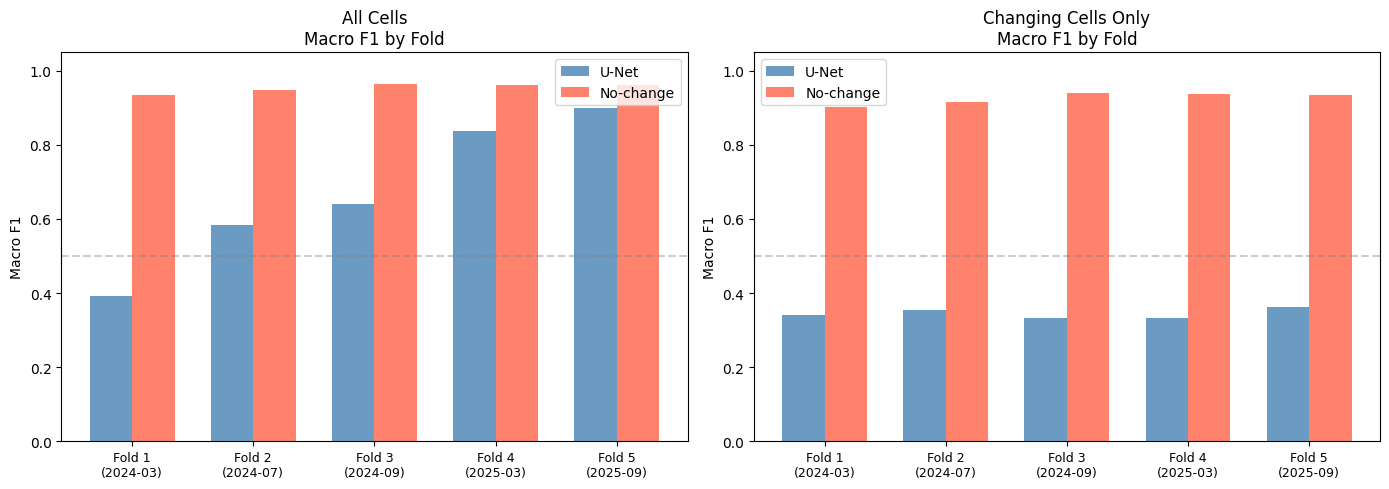

Figure saved.


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cutoffs = results_df["train_cutoff"].values

for ax, subset, title in zip(
    axes,
    ["all", "changing"],
    ["All Cells", "Changing Cells Only"]
):
    unet_f1 = results_df[f"unet_{subset}_macro_f1"].values
    nc_f1   = results_df[f"nc_{subset}_macro_f1"].values

    x = np.arange(len(cutoffs))
    w = 0.35
    ax.bar(x - w/2, unet_f1, w, label="U-Net",         color="steelblue", alpha=0.8)
    ax.bar(x + w/2, nc_f1,   w, label="No-change",     color="tomato",    alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([f"Fold {i+1}\n({c})" for i, c in enumerate(cutoffs)],
                        fontsize=9)
    ax.set_ylabel("Macro F1")
    ax.set_title(f"{title}\nMacro F1 by Fold", fontsize=12)
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.axhline(0.5, color="grey", linestyle="--", alpha=0.4, label="random")

plt.tight_layout()
plt.savefig(REPORTS / "unet_crossval_comparison.png", dpi=150)
plt.show()
print("Figure saved.")

In [8]:
# ── Evaluate ONLY on cell-months where a change actually happened ─────────────
# This is the real test: on the 255 rows where control flipped,
# does the U-Net predict the new label correctly?
# No-change baseline scores 0% here by definition.

print("=" * 60)
print("EVALUATION ON CHANGE EVENTS ONLY")
print("=" * 60)
print("No-change baseline accuracy on these rows: 0.000 (by definition)")
print()

# Identify all change events in the target
target_sorted = target.sort_values(["priogrid_gid", "year_month"]).copy()
target_sorted["prev"] = target_sorted.groupby("priogrid_gid")["target"].shift(1)
target_sorted["is_change"] = (
    target_sorted["prev"].notna() &
    (target_sorted["target"] != target_sorted["prev"])
)
change_events = target_sorted[target_sorted["is_change"]][
    ["priogrid_gid", "year_month", "prev", "target"]
].copy()
change_events["true_int"] = change_events["target"].map(LABEL_MAP)
change_events["prev_int"] = change_events["prev"].map(LABEL_MAP)

print(f"Total change events in full dataset: {len(change_events)}")
print(f"Transition breakdown:")
trans = (change_events["prev"] + " -> " + change_events["target"]).value_counts()
print(trans.to_string())

# Load saved predictions for each fold and evaluate on change events
print()
change_results = []

for fold_i, train_cutoff in enumerate(FOLD_CUTOFFS):
    # Get val months for this fold
    all_months = sorted(target["year_month"].unique())
    val_months = [m for m in all_months if m > train_cutoff]

    # Change events in val period
    val_changes = change_events[change_events["year_month"].isin(val_months)].copy()
    n_changes = len(val_changes)

    if n_changes == 0:
        print(f"Fold {fold_i+1} ({train_cutoff}): no change events in val period")
        continue

    # Load checkpoint and rebuild labelled dataset for this fold
    ckpt_path = CHECKPOINTS / f"unet_fold{fold_i+1}_{train_cutoff}.pt"
    if not ckpt_path.exists():
        print(f"Fold {fold_i+1}: checkpoint not found, skipping")
        continue

    # Rebuild rasters
    (X_train, y_train, m_train,
     X_val, y_val, m_val,
     month_keys, train_idx, val_idx, labelled) = build_rasters(train_cutoff)

    # Reload model
    model_eval, _, _, _ = build_model(labelled, train_cutoff)
    model_eval.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model_eval.eval()

    # Get predictions for all val months
    val_dataset = MyanmarRasterDataset(X_val, y_val, m_val, augment=False)
    val_loader  = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    # Collect predictions with month and gid info
    all_preds_list = []
    val_month_list = [month_keys[i] for i in val_idx]

    with torch.no_grad():
        for batch_i, (X_batch, y_batch, mask_batch) in enumerate(val_loader):
            X_batch    = X_batch.to(DEVICE)
            logits     = model_eval(X_batch)
            probs      = torch.softmax(logits, dim=1)
            preds      = torch.argmax(probs, dim=1).cpu().numpy()
            masks_b    = mask_batch.numpy()

            for b in range(X_batch.shape[0]):
                month_idx = batch_i * BATCH_SIZE + b
                if month_idx >= len(val_month_list):
                    break
                ym = val_month_list[month_idx]
                rows, cols = np.where(masks_b[b] == 1)
                for r, c in zip(rows, cols):
                    # reverse lookup local (r,c) -> gid
                    gid = None
                    for g, pos in gid_to_local.items():
                        if pos["local_row"] == r and pos["local_col"] == c:
                            gid = g
                            break
                    if gid is not None:
                        all_preds_list.append({
                            "priogrid_gid": gid,
                            "year_month":   ym,
                            "pred_int":     int(preds[b, r, c])
                        })

    preds_df = pd.DataFrame(all_preds_list)

    # Join predictions to change events
    val_changes_pred = val_changes.merge(
        preds_df, on=["priogrid_gid", "year_month"], how="left"
    ).dropna(subset=["pred_int"])

    if len(val_changes_pred) == 0:
        print(f"Fold {fold_i+1}: no matched predictions for change events")
        continue

    val_changes_pred["pred_int"] = val_changes_pred["pred_int"].astype(int)
    true = val_changes_pred["true_int"].values
    pred = val_changes_pred["pred_int"].values

    acc      = accuracy_score(true, pred)
    macro_f1 = f1_score(true, pred, average="macro",
                        labels=[0,1,2], zero_division=0)
    n_correct = (true == pred).sum()

    print(f"Fold {fold_i+1} ({train_cutoff}) — {len(val_changes_pred)} change events in val:")
    print(f"  U-Net accuracy:  {acc:.3f}  ({n_correct}/{len(val_changes_pred)} correct)")
    print(f"  U-Net macro F1:  {macro_f1:.3f}")
    print(f"  No-change:       0.000 (by definition)")
    print(f"  Transition breakdown:")
    for _, row in val_changes_pred.groupby(
        val_changes_pred["prev"] + " -> " + val_changes_pred["target"]
    ).size().reset_index(name="n").iterrows():
        correct = val_changes_pred[
            (val_changes_pred["prev"] + " -> " + val_changes_pred["target"] == row.iloc[0]) &
            (val_changes_pred["true_int"] == val_changes_pred["pred_int"])
        ]
        print(f"    {row.iloc[0]}: {row['n']} events, {len(correct)} correct")
    print()

    change_results.append({
        "fold": fold_i + 1,
        "cutoff": train_cutoff,
        "n_change_events": len(val_changes_pred),
        "unet_accuracy": round(acc, 3),
        "unet_macro_f1": round(macro_f1, 3),
    })

if change_results:
    print("=" * 60)
    print("SUMMARY: U-Net on change events only")
    print("=" * 60)
    cr_df = pd.DataFrame(change_results)
    print(cr_df.to_string(index=False))
    print(f"\nMean U-Net accuracy on change events: {cr_df['unet_accuracy'].mean():.3f}")
    print(f"No-change baseline on change events:  0.000 (always)")

EVALUATION ON CHANGE EVENTS ONLY
No-change baseline accuracy on these rows: 0.000 (by definition)

Total change events in full dataset: 255
Transition breakdown:
gov -> opo          69
opo -> gov          49
uncertain -> gov    45
uncertain -> opo    42
opo -> uncertain    37
gov -> uncertain    13

Fold 1 (2024-03) — 181 change events in val:
  U-Net accuracy:  0.315  (57/181 correct)
  U-Net macro F1:  0.294
  No-change:       0.000 (by definition)
  Transition breakdown:
    gov -> opo: 51 events, 8 correct
    gov -> uncertain: 11 events, 5 correct
    opo -> gov: 39 events, 14 correct
    opo -> uncertain: 24 events, 8 correct
    uncertain -> gov: 39 events, 20 correct
    uncertain -> opo: 17 events, 2 correct

Fold 2 (2024-07) — 122 change events in val:
  U-Net accuracy:  0.328  (40/122 correct)
  U-Net macro F1:  0.309
  No-change:       0.000 (by definition)
  Transition breakdown:
    gov -> opo: 34 events, 7 correct
    gov -> uncertain: 8 events, 5 correct
    opo -> gov:

PRE-COUP TEMPORAL VALIDATION
Input: 2018-2020 average (pre-coup baseline)
Model: Fold 5 U-Net (trained on post-coup data)

UCDP events in 2018-2020: 296 (across 3 years)
Unique cells with any activity: 41

Building pre-coup feature averages per cell...
Cells with pre-coup activity: 41

Feature summary:
       total_events  total_fatalities  events_gov  events_nug  events_ula  \
count        41.000            41.000      41.000        41.0      41.000   
mean          0.201             0.621       0.199         0.0       0.113   
std           0.290             1.216       0.287         0.0       0.279   
min           0.028             0.000       0.028         0.0       0.000   
25%           0.056             0.028       0.056         0.0       0.000   
50%           0.111             0.167       0.111         0.0       0.000   
75%           0.194             0.750       0.194         0.0       0.083   
max           1.583             6.528       1.583         0.0       1.444   

  

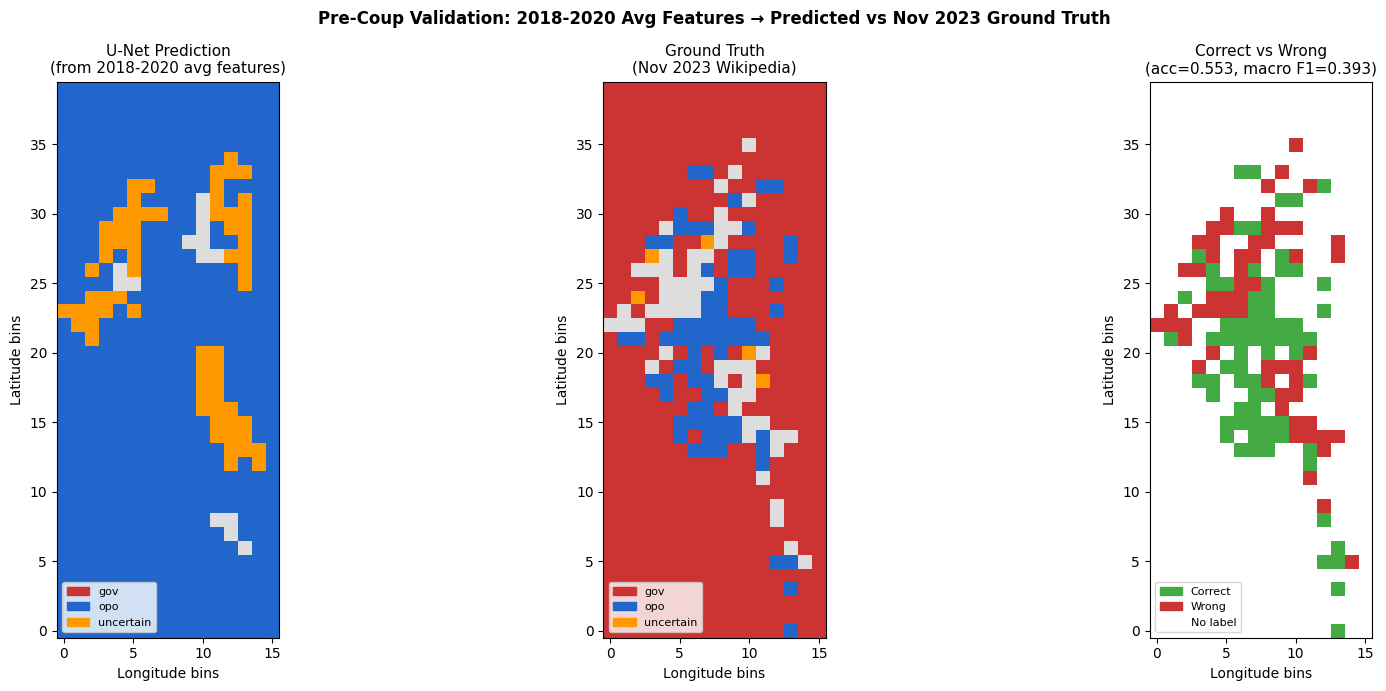


Figure saved -> reports/figures/precoup_validation.png


In [9]:
# ── PRE-COUP TEMPORAL VALIDATION ──────────────────────────────────────────────
#
# Hypothesis: if the U-Net learned a general relationship between conflict
# event patterns and territorial control (rather than memorising geography),
# then feeding it pre-coup UCDP features should produce a control map that
# roughly matches the November 2023 Wikipedia snapshot.
#
# Test:
#   Input:  UCDP features averaged over 2018-2020 (pre-coup baseline)
#   Model:  Fold 5 U-Net (trained on Nov 2023 - Sep 2025)
#   Output: Predicted control map
#   Compare: Against November 2023 Wikipedia ground truth

import matplotlib.patches as mpatches

print("=" * 60)
print("PRE-COUP TEMPORAL VALIDATION")
print("Input: 2018-2020 average (pre-coup baseline)")
print("Model: Fold 5 U-Net (trained on post-coup data)")
print("=" * 60)

# ── Step 1: Load pre-coup UCDP data ───────────────────────────────────────────
ucdp_path = PROJECT_ROOT / "data" / "raw" / "ucdp" / "GEDEvent_myanmar_merged.csv"
ucdp_full = pd.read_csv(ucdp_path)
ucdp_full["year_month"] = pd.to_datetime(ucdp_full["date_start"]).dt.to_period("M").astype(str)

PRE_COUP_YEARS = [2018, 2019, 2020]
ucdp_precoup = ucdp_full[ucdp_full["year"].isin(PRE_COUP_YEARS)].copy()
N_MONTHS = 36   # 3 years x 12 months

print(f"\nUCDP events in 2018-2020: {len(ucdp_precoup)} (across 3 years)")
print(f"Unique cells with any activity: {ucdp_precoup['priogrid_gid'].nunique()}")

# ── Step 2: Build actor flags ─────────────────────────────────────────────────
GOV_ACTORS = ["Government of Myanmar (Burma)"]
NUG_ACTORS = ["NUG", "ABSDF"]
ULA_ACTORS = ["ULA"]
KIO_ACTORS = ["KIO"]

# ── Step 3: Aggregate pre-coup features per cell ──────────────────────────────
# Sum all events across 2018-2020 then divide by 36 to get monthly average
print("\nBuilding pre-coup feature averages per cell...")

grp = ucdp_precoup.groupby("priogrid_gid")

feats_precoup = pd.DataFrame(index=ucdp_precoup["priogrid_gid"].unique())
feats_precoup.index.name = "priogrid_gid"

feats_precoup["total_events"]     = grp.size() / N_MONTHS
feats_precoup["total_fatalities"] = grp["best"].sum() / N_MONTHS
feats_precoup["events_gov"]       = grp.apply(
    lambda x: (x["side_a"].isin(GOV_ACTORS).sum() +
               x["side_b"].isin(GOV_ACTORS).sum())
) / N_MONTHS
feats_precoup["events_nug"]       = grp.apply(
    lambda x: (x["side_a"].isin(NUG_ACTORS).sum() +
               x["side_b"].isin(NUG_ACTORS).sum())
) / N_MONTHS
feats_precoup["events_ula"]       = grp.apply(
    lambda x: (x["side_a"].isin(ULA_ACTORS).sum() +
               x["side_b"].isin(ULA_ACTORS).sum())
) / N_MONTHS
feats_precoup["events_kio"]       = grp.apply(
    lambda x: (x["side_a"].isin(KIO_ACTORS).sum() +
               x["side_b"].isin(KIO_ACTORS).sum())
) / N_MONTHS
feats_precoup["gov_vs_civilians"] = grp.apply(
    lambda x: ((x["side_a"].isin(GOV_ACTORS)) &
               (x["side_b"] == "Civilians")).sum()
) / N_MONTHS
feats_precoup["gov_event_share"] = (
    feats_precoup["events_gov"] /
    feats_precoup["total_events"].replace(0, np.nan)
).fillna(0)

# Use same month as lag (no true previous month available)
feats_precoup["total_events_lag1"]     = feats_precoup["total_events"]
feats_precoup["total_fatalities_lag1"] = feats_precoup["total_fatalities"]

feats_precoup = feats_precoup.fillna(0).reset_index()

print(f"Cells with pre-coup activity: {len(feats_precoup)}")
print(f"\nFeature summary:")
print(feats_precoup[INPUT_FEATURES].describe().round(3))

# ── Step 4: Normalise using fold 5 training statistics ────────────────────────
print("\nRebuilding fold 5 normalisation statistics...")
(X_tr, y_tr, m_tr, X_v, y_v, m_v,
 month_keys_f5, train_idx_f5, val_idx_f5,
 labelled_f5) = build_rasters("2025-09")

train_mask_f5 = labelled_f5["year_month"] <= "2025-09"
feat_means_f5 = labelled_f5.loc[train_mask_f5, INPUT_FEATURES].mean()
feat_stds_f5  = labelled_f5.loc[train_mask_f5, INPUT_FEATURES].std().replace(0, 1)

feats_norm = feats_precoup.copy()
for col in INPUT_FEATURES:
    if col in feats_norm.columns:
        feats_norm[col] = (feats_norm[col] - feat_means_f5[col]) / feat_stds_f5[col]
    else:
        feats_norm[col] = 0.0

# ── Step 5: Build raster ──────────────────────────────────────────────────────
print("\nBuilding pre-coup raster...")
X_raster = np.zeros((PAD_H, PAD_W, NUM_CHANNELS), dtype=np.float32)

for _, row in feats_norm.iterrows():
    gid = row["priogrid_gid"]
    if gid not in gid_to_local:
        continue
    lr = gid_to_local[gid]["local_row"]
    lc = gid_to_local[gid]["local_col"]
    X_raster[lr, lc, :] = row[INPUT_FEATURES].values

X_raster = np.transpose(X_raster, (2, 0, 1))  # (C, H, W)
X_tensor = torch.from_numpy(
    X_raster[np.newaxis, :, :, :]
).float().to(DEVICE)

n_active = int((X_raster.sum(axis=0) != 0).sum())
print(f"  Raster shape: {X_tensor.shape}")
print(f"  Cells with any pre-coup activity: {n_active}")

# ── Step 6: Load fold 5 model and run inference ───────────────────────────────
print("\nLoading fold 5 model and running inference...")
ckpt_path = CHECKPOINTS / "unet_fold5_2025-09.pt"
model_precoup, _, _, _ = build_model(labelled_f5, "2025-09")
model_precoup.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
model_precoup.eval()

with torch.no_grad():
    logits = model_precoup(X_tensor)
    probs  = torch.softmax(logits, dim=1)
    preds  = torch.argmax(probs, dim=1)

pred_map = preds[0].cpu().numpy()    # (H, W)
prob_map = probs[0].cpu().numpy()    # (3, H, W)
conf_map = prob_map.max(axis=0)      # (H, W)
print("Inference complete.")

# ── Step 7: Load November 2023 ground truth ───────────────────────────────────
nov23_labels = labelled_f5[labelled_f5["year_month"] == "2023-11"][
    ["priogrid_gid", "target", "label_int"]
].copy()

gt_raster = np.full((PAD_H, PAD_W), fill_value=-1, dtype=np.int64)
gt_mask   = np.zeros((PAD_H, PAD_W), dtype=np.uint8)

for _, row in nov23_labels.iterrows():
    gid = row["priogrid_gid"]
    if gid not in gid_to_local:
        continue
    lr = gid_to_local[gid]["local_row"]
    lc = gid_to_local[gid]["local_col"]
    gt_raster[lr, lc] = row["label_int"]
    gt_mask[lr, lc]   = 1

# ── Step 8: Evaluate ──────────────────────────────────────────────────────────
valid = gt_mask == 1
true  = gt_raster[valid]
pred  = pred_map[valid]

acc      = accuracy_score(true, pred)
macro_f1 = f1_score(true, pred, average="macro", labels=[0,1,2], zero_division=0)
report   = classification_report(true, pred, labels=[0,1,2],
                                  target_names=CLASS_NAMES,
                                  digits=3, zero_division=0)

majority     = nov23_labels["target"].value_counts().index[0]
majority_acc = (nov23_labels["target"] == majority).mean()

print(f"\n{'='*60}")
print(f"RESULTS: Pre-coup (2018-2020 avg) -> Nov 2023 ground truth")
print(f"{'='*60}")
print(f"Labelled cells evaluated: {valid.sum()}")
print(f"Accuracy:                 {acc:.3f}")
print(f"Macro F1:                 {macro_f1:.3f}")
print(f"Majority class baseline:  {majority_acc:.3f} (always '{majority}')")
print(f"\nClassification report:")
print(report)

# Also compare to fold 5 in-distribution performance
print(f"\nFor reference — Fold 5 in-distribution (Oct-Mar 2026):")
print(f"  Accuracy: 0.900  Macro F1: 0.961 (no-change: 0.961)")

# ── Step 9: Visualise ─────────────────────────────────────────────────────────
label_cmap   = mcolors.ListedColormap(["#CC3333", "#2266CC", "#FF9900", "#DDDDDD"])
label_bounds = [-1.5, -0.5, 0.5, 1.5, 2.5]
label_norm   = mcolors.BoundaryNorm(label_bounds, label_cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle(
    "Pre-Coup Validation: 2018-2020 Avg Features → Predicted vs Nov 2023 Ground Truth",
    fontsize=12, fontweight="bold"
)

axes[0].imshow(pred_map, cmap=label_cmap, norm=label_norm, origin="lower")
axes[0].set_title(f"U-Net Prediction\n(from 2018-2020 avg features)", fontsize=11)

axes[1].imshow(gt_raster, cmap=label_cmap, norm=label_norm, origin="lower")
axes[1].set_title("Ground Truth\n(Nov 2023 Wikipedia)", fontsize=11)

diff_map    = np.where(gt_mask == 1,
                       (pred_map == gt_raster).astype(int) * 2 - 1, -2)
diff_cmap   = mcolors.ListedColormap(["white", "#CC3333", "#44AA44"])
diff_bounds = [-2.5, -1.5, -0.5, 1.5]
diff_norm   = mcolors.BoundaryNorm(diff_bounds, diff_cmap.N)
axes[2].imshow(diff_map, cmap=diff_cmap, norm=diff_norm, origin="lower")
axes[2].set_title(
    f"Correct vs Wrong\n(acc={acc:.3f}, macro F1={macro_f1:.3f})", fontsize=11
)

legend_patches = [
    mpatches.Patch(color="#CC3333", label="gov"),
    mpatches.Patch(color="#2266CC", label="opo"),
    mpatches.Patch(color="#FF9900", label="uncertain"),
]
axes[0].legend(handles=legend_patches, loc="lower left", fontsize=8)
axes[1].legend(handles=legend_patches, loc="lower left", fontsize=8)

diff_patches = [
    mpatches.Patch(color="#44AA44", label="Correct"),
    mpatches.Patch(color="#CC3333", label="Wrong"),
    mpatches.Patch(color="white",   label="No label"),
]
axes[2].legend(handles=diff_patches, loc="lower left", fontsize=8)

for ax in axes:
    ax.set_xlabel("Longitude bins")
    ax.set_ylabel("Latitude bins")

plt.tight_layout()
plt.savefig(REPORTS / "precoup_validation.png", dpi=150)
plt.show()
print(f"\nFigure saved -> reports/figures/precoup_validation.png")

In [11]:
# Rebuild the full array for fold 5
(X_tr_f5, y_tr_f5, m_tr_f5,
 X_val_f5, y_val_f5, m_val_f5,
 month_keys_f5, train_idx_f5, val_idx_f5,
 labelled_f5) = build_rasters("2025-09")

# Stack train and val back together to get full array
X_array = np.concatenate([X_tr_f5, X_val_f5], axis=0)
all_month_keys = (
    [month_keys_f5[i] for i in train_idx_f5] +
    [month_keys_f5[i] for i in val_idx_f5]
)

# Find November 2023 index
nov23_idx = all_month_keys.index("2023-11")
X_nov23 = torch.from_numpy(
    X_array[nov23_idx][np.newaxis, :, :, :]
).float().to(DEVICE)

model_precoup.eval()
with torch.no_grad():
    logits = model_precoup(X_nov23)
    probs  = torch.softmax(logits, dim=1)
    preds  = torch.argmax(probs, dim=1)

pred_nov23 = preds[0].cpu().numpy()
valid = gt_mask == 1
acc_nov23 = accuracy_score(gt_raster[valid], pred_nov23[valid])
print(f"Fold 5 model on actual Nov 2023 input: {acc_nov23:.3f}")
print(f"Fold 5 model on pre-coup input:        0.553")

Fold 5 model on actual Nov 2023 input: 0.985
Fold 5 model on pre-coup input:        0.553
